<a href="https://colab.research.google.com/github/Mageed-Ghaleb/OptimizationSystems-Course/blob/main/LP_Abstract_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pyomo ortools cvxpy highspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.3/323.3 kB 17.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.4 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.4 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.4 which is incompatible.


In [ ]:
from pyomo.environ import (
    ConcreteModel, AbstractModel, Var, Objective, Constraint, NonNegativeReals, NonNegativeIntegers, Binary, minimize, maximize, Set, value, Param
)
from pyomo.environ import SolverFactory

Example: Transportation (warehouses → stores)

A company ships product from warehouses to stores. Shipping costs differ by route. Each warehouse has limited supply; each store has demand that must be met. Decide how much to ship on each route to minimize total cost.

set W := W1 W2 ;
set S := S1 S2 S3 ;

param supply :=
  W1 35
  W2 50
;

param demand :=
  S1 30
  S2 40
  S3 10
;

param cost :   S1  S2  S3 :=
        W1     4   6   9
        W2     5   4   7
;


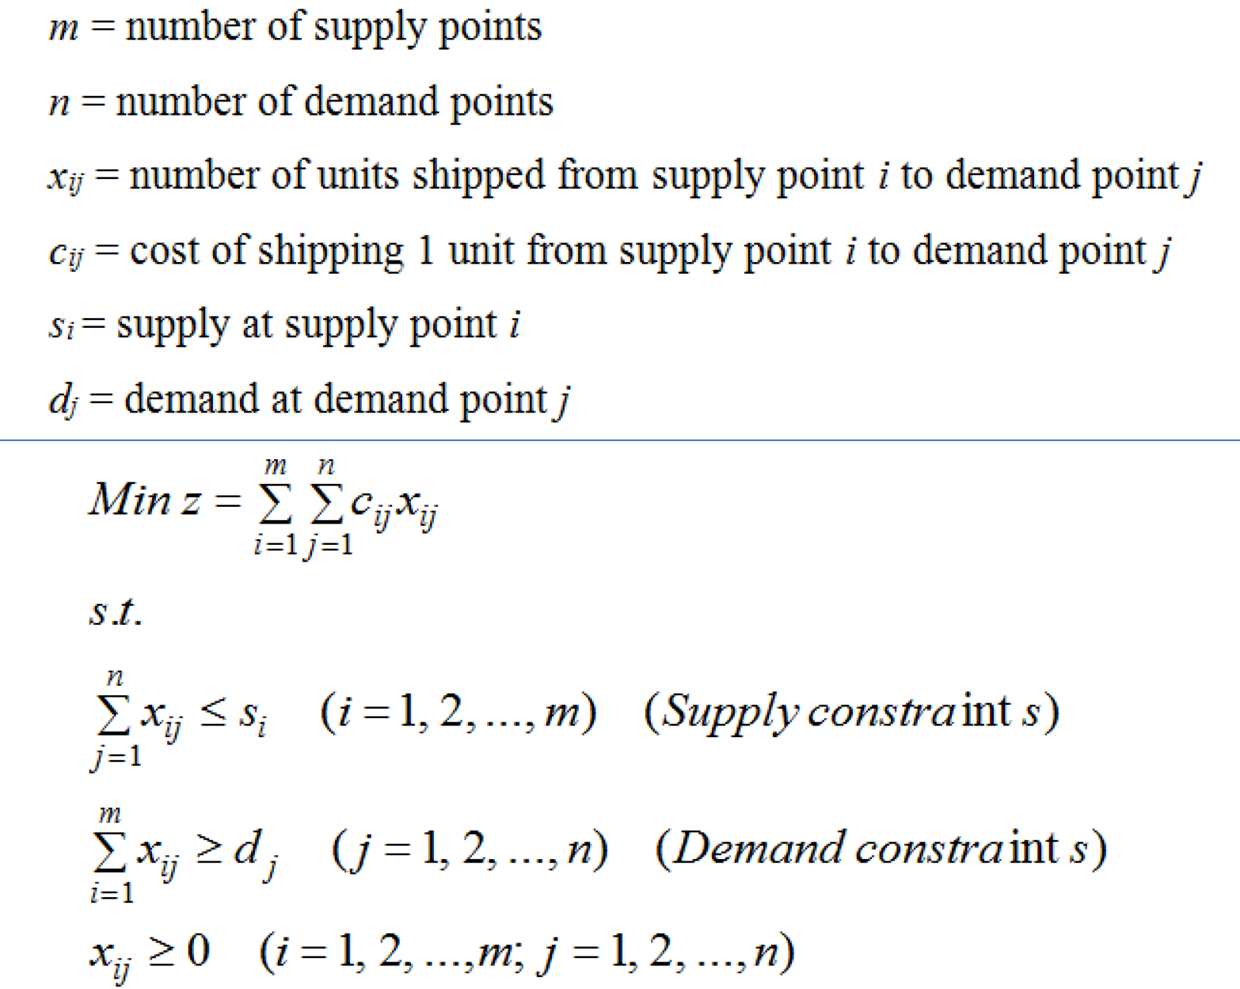

In [ ]:
dat_text = """
set W := W1 W2 W3 W4 W5;
set S := S1 S2 S3 S4 S5 S6 S7 S8 S9 S10;

param supply :=
  W1 35
  W2 50
  W3 40
  W4 35
  W5 45
;

param demand :=
  S1 30
  S2 40
  S3 10
  S4 20
  S5 15
  S6 20
  S7 30
  S8 35
  S9 15
  S10 10
;

param cost :   S1  S2  S3  S4  S5  S6  S7  S8  S9  S10 :=
        W1     4   6   9   4   6   9   4   6   9   8
        W2     5   4   7   5   4   7   5   4   7   9
        W3     2   4   7   5   4   7   5   4   7   9
        W4     5   1   7   5   4   7   5   4   7   9
        W5     5   4   7   3   4   7   5   4   7   9
;
"""

with open("/content/transport_lp.dat", "w") as f:
  f.write(dat_text)

In [ ]:
!ls -l /content

total 16
drwxr-xr-x 1 root root 4096 Dec 11 14:34  sample_data
-rw-r--r-- 1 root root  210 Jan 17 13:14 'transport_lp (1).txt'
-rw-r--r-- 1 root root  552 Jan 17 14:28  transport_lp.dat
-rw-r--r-- 1 root root  210 Jan 17 13:12  transport_lp.txt


In [ ]:
# from google.colab import files
# uploaded = files.upload()
# print(uploaded)

In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")

In [ ]:
model_lp = AbstractModel()

model_lp.W = Set()
model_lp.S = Set()

model_lp.supply = Param(model_lp.W, within=NonNegativeReals)
model_lp.demand = Param(model_lp.S, within=NonNegativeReals)
model_lp.cost = Param(model_lp.W, model_lp.S, within=NonNegativeReals)

### DV:
model_lp.ship = Var(model_lp.W, model_lp.S, within=NonNegativeReals)

### Objective Function
def obj_rule(m):
  return sum(m.cost[w,s] * m.ship[w,s] for w in m.W for s in m.S)

model_lp.obj = Objective(rule=obj_rule, sense=minimize)

### Supply
def supply_rule(m, w):
  return sum(m.ship[w,s] for s in m.S) <= m.supply[w]
#
model_lp.Supply = Constraint(model_lp.W, rule=supply_rule)

### Demand
def demand_rule(m, s):
  return sum(m.ship[w,s] for w in m.W) >= m.demand[s]
#
model_lp.Demand = Constraint(model_lp.S, rule=demand_rule)

In [ ]:
#### Create instance + solve (HiGHS)
inst_lp = model_lp.create_instance("/content/transport_lp.dat")

solver = SolverFactory("highs")
results = solver.solve(inst_lp, tee=False)

print("Status:", results.solver.status)
print("Solution Optimiality:", results.solver.termination_condition)
print("Objective Value:", value(inst_lp.obj))
for w in inst_lp.W:
  for s in inst_lp.S:
    # print(value(inst_lp.ship[w,s]))
    x_value = value(inst_lp.ship[w,s])
    print(f"ship[{w},{s}]={x_value}")
#


Status: error
Solution Optimiality: infeasible
Objective Value: 895.0
ship[W1,S1]=0.0
ship[W1,S2]=0.0
ship[W1,S3]=0.0
ship[W1,S4]=0.0
ship[W1,S5]=0.0
ship[W1,S6]=0.0
ship[W1,S7]=25.0
ship[W1,S8]=0.0
ship[W1,S9]=0.0
ship[W1,S10]=10.0
ship[W2,S1]=0.0
ship[W2,S2]=0.0
ship[W2,S3]=10.0
ship[W2,S4]=0.0
ship[W2,S5]=15.0
ship[W2,S6]=0.0
ship[W2,S7]=0.0
ship[W2,S8]=10.0
ship[W2,S9]=15.0
ship[W2,S10]=0.0
ship[W3,S1]=30.0
ship[W3,S2]=5.0
ship[W3,S3]=0.0
ship[W3,S4]=0.0
ship[W3,S5]=0.0
ship[W3,S6]=5.0
ship[W3,S7]=0.0
ship[W3,S8]=0.0
ship[W3,S9]=0.0
ship[W3,S10]=0.0
ship[W4,S1]=0.0
ship[W4,S2]=35.0
ship[W4,S3]=0.0
ship[W4,S4]=0.0
ship[W4,S5]=0.0
ship[W4,S6]=0.0
ship[W4,S7]=0.0
ship[W4,S8]=0.0
ship[W4,S9]=0.0
ship[W4,S10]=0.0
ship[W5,S1]=0.0
ship[W5,S2]=0.0
ship[W5,S3]=0.0
ship[W5,S4]=20.0
ship[W5,S5]=0.0
ship[W5,S6]=15.0
ship[W5,S7]=5.0
ship[W5,S8]=25.0
ship[W5,S9]=0.0
ship[W5,S10]=0.0


In [ ]:
import pandas as pd
from pyomo.environ import value
#
rows = []
for w in inst_lp.W:
    for s in inst_lp.S:
        rows.append({
            "w": str(w),
            "s": str(s),
            "ship": float(value(inst_lp.ship[w, s]))
        })
#
df_ship = pd.DataFrame(rows)
df_ship_pos = df_ship[df_ship["ship"] > 1e-9].reset_index(drop=True)
df_ship_pos

,w,s,ship
0,W1,S7,25.0
1,W1,S10,10.0
2,W2,S3,10.0
3,W2,S5,15.0
4,W2,S8,10.0
5,W2,S9,15.0
6,W3,S1,30.0
7,W3,S2,5.0
8,W3,S6,5.0
9,W4,S2,35.0
